# Face Preprocessing — Stage 2

This notebook performs Stage 2 of the pipeline:

1. Load a subset manifest (`pilot_manifest.csv` or `final_manifest.csv`)
2. Extract video frames at a fixed FPS
3. Detect the main face in each frame
4. Save face crops
5. Build:
   - `frame_manifest.csv`
   - `face_manifest.csv`

Recommended workflow:
- run this notebook on `pilot_manifest.csv` first
- inspect outputs manually
- then switch to `final_manifest.csv`

## Notes

- This notebook is practical and reproducible.
- It tries a detector backend in this order:
  1. `insightface` if installed
  2. OpenCV Haar cascade fallback
- If no face is found, the frame is still recorded in the frame manifest, but no face crop is written.
- Existing extracted frames and face crops are reused unless overwrite flags are enabled.

In [1]:
%pip install insightface onnxruntime-gpu -q

/home/n.salikhova@innopolis.university/deepfake-emotion-robustness/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import math
from typing import Optional, Dict, List, Tuple

import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

In [3]:
# =========================
# Configuration
# =========================
PROJECT_ROOT = Path(".").resolve().parent if Path(".").resolve().name == "notebooks" else Path(".").resolve()
DATASET_ROOT = PROJECT_ROOT / Path("exports")

SUBSET_NAME = "final"   # change to "final" later
MANIFEST_PATH = DATASET_ROOT / SUBSET_NAME / "csv" / f"{SUBSET_NAME}_manifest_export.csv"

PROCESSED_ROOT = PROJECT_ROOT / "datasets/processed" / SUBSET_NAME
FRAMES_ROOT = PROCESSED_ROOT / "datasets/frames"
FACES_ROOT = PROCESSED_ROOT / "datasets/faces"
METADATA_ROOT = PROJECT_ROOT / "datasets/metadata"

FRAME_MANIFEST_OUT = METADATA_ROOT / f"{SUBSET_NAME}_frame_manifest.csv"
FACE_MANIFEST_OUT = METADATA_ROOT / f"{SUBSET_NAME}_face_manifest.csv"

TARGET_FPS = 5.0
FRAME_EXT = ".jpg"
FACE_EXT = ".jpg"
JPEG_QUALITY = 95

FACE_MARGIN = 0.15
MIN_FACE_SIZE = 32

MAX_VIDEOS = None
OVERWRITE_FRAMES = False
OVERWRITE_FACES = False

SANITY_SAMPLES = 12

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MANIFEST_PATH:", MANIFEST_PATH)
print("PROCESSED_ROOT:", PROCESSED_ROOT)

PROJECT_ROOT: /home/n.salikhova@innopolis.university/deepfake-emotion-robustness
MANIFEST_PATH: /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/exports/final/csv/final_manifest_export.csv
PROCESSED_ROOT: /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/datasets/processed/final


In [4]:
assert MANIFEST_PATH.exists(), f"Manifest not found: {MANIFEST_PATH}"

FRAMES_ROOT.mkdir(parents=True, exist_ok=True)
FACES_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_ROOT.mkdir(parents=True, exist_ok=True)

manifest_df = pd.read_csv(MANIFEST_PATH)
print(f"Loaded {len(manifest_df):,} rows from {MANIFEST_PATH}")

if MAX_VIDEOS is not None:
    manifest_df = manifest_df.head(MAX_VIDEOS).copy()
    print(f"Trimmed to {len(manifest_df):,} rows for debugging")

display(manifest_df.head())

Loaded 800 rows from /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/exports/final/csv/final_manifest_export.csv


,video_id,path,relative_path,split,label,source_subset,manipulation_family,manipulation_type,identity,source_identity,target_identity,file_ext,frame_count,fps,duration_sec,width,height,file_size_bytes,file_size_mb,split_strategy
0,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,videos/fake/TalkingFace/id35_0005_test_id07802...,Celeb-synthesis/TalkingFace/EDTalk/id35_0005_t...,train,fake,Celeb-synthesis,TalkingFace,EDTalk,id35,id35,id07802,.mp4,147,25.000000,5.880000,256,256,778432,0.742371,identity_disjoint
1,Celeb-synthesis__TalkingFace__AniTalker__id48_...,videos/fake/TalkingFace/id48_0002_test_id04656...,Celeb-synthesis/TalkingFace/AniTalker/id48_000...,train,fake,Celeb-synthesis,TalkingFace,AniTalker,id48,id48,id04656,.mp4,337,25.000000,13.480000,256,256,336317,0.320737,identity_disjoint
2,Celeb-real__id50_0005__3870d23c,videos/real/Celeb-real/id50_0005.mp4,Celeb-real/id50_0005.mp4,test,real,Celeb-real,NaN,Celeb-real,id50,id50,NaN,.mp4,489,29.599987,16.520278,856,478,1607745,1.533265,identity_disjoint
3,Celeb-synthesis__FaceReenact__TPSMM__id23_id19...,videos/fake/FaceReenact/id23_id19_0000.mp4,Celeb-synthesis/FaceReenact/TPSMM/id23_id19_00...,test,fake,Celeb-synthesis,FaceReenact,TPSMM,id23,id23,id19,.mp4,326,29.830000,10.928595,256,256,79963,0.076259,identity_disjoint
4,Celeb-real__id20_0001__5e2f4954,videos/real/Celeb-real/id20_0001.mp4,Celeb-real/id20_0001.mp4,train,real,Celeb-real,NaN,Celeb-real,id20,id20,NaN,.mp4,306,30.000000,10.200000,856,476,1540147,1.468799,identity_disjoint


## Face detector

The notebook tries:

- `insightface` if available
- otherwise OpenCV Haar cascade

In [5]:
class FaceDetector:
    def __init__(self):
        self.backend = None
        self.detector = None
        self._init_backend()

    def _init_backend(self):
        try:
            from insightface.app import FaceAnalysis
            app = FaceAnalysis(providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
            app.prepare(ctx_id=0, det_size=(640, 640))
            self.backend = "insightface"
            self.detector = app
            print("Face detector backend: insightface")
            return
        except Exception as e:
            print(f"InsightFace unavailable, falling back to OpenCV Haar cascade. Reason: {e}")

        cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        if not Path(cascade_path).exists():
            raise FileNotFoundError(f"Haar cascade not found: {cascade_path}")
        self.backend = "opencv_haar"
        self.detector = cv2.CascadeClassifier(cascade_path)
        print("Face detector backend: opencv_haar")

    def detect(self, image_bgr: np.ndarray) -> List[Dict]:
        if self.backend == "insightface":
            faces = self.detector.get(image_bgr)
            results = []
            for f in faces:
                x1, y1, x2, y2 = map(int, f.bbox)
                results.append({"bbox": [x1, y1, x2, y2], "score": float(getattr(f, "det_score", 1.0))})
            return results

        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        dets = self.detector.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(MIN_FACE_SIZE, MIN_FACE_SIZE)
        )
        results = []
        for (x, y, w, h) in dets:
            results.append({"bbox": [int(x), int(y), int(x + w), int(y + h)], "score": 1.0})
        return results

detector = FaceDetector()

2026-04-14 12:39:07.077016812 [W:onnxruntime:Default, device_discovery.cc:132 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/ACPI0004:00/MSFT1000:00/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename ""5620e0c7-8062-4dce-aeb7-520c7ef76171"" dit not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+


download_path: /home/n.salikhova@innopolis.university/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:08<00:00, 34319.70KB/s]
2026-04-14 12:39:20.252927305 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/.venv/lib/python3.11/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory

2026-04-14 12:39:20.702973831 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/.venv/lib/python3.11/site-packages/onnxruntime/cap

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/n.salikhova@innopolis.university/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/n.salikhova@innopolis.university/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0


2026-04-14 12:39:20.735741032 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/.venv/lib/python3.11/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory

2026-04-14 12:39:20.765436925 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/.venv/lib/python3.11/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/n.salikhova@innopolis.university/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/n.salikhova@innopolis.university/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


2026-04-14 12:39:20.897384469 [E:onnxruntime:Default, provider_bridge_ort.cc:2359 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1952 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/.venv/lib/python3.11/site-packages/onnxruntime/capi/libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory



find model: /home/n.salikhova@innopolis.university/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Face detector backend: insightface


In [6]:
def choose_main_face(detections: List[Dict], image_shape: Tuple[int, int, int]) -> Optional[Dict]:
    if not detections:
        return None

    h, w = image_shape[:2]
    cx_img, cy_img = w / 2.0, h / 2.0

    def score(det):
        x1, y1, x2, y2 = det["bbox"]
        area = max(0, x2 - x1) * max(0, y2 - y1)
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        center_penalty = math.hypot(cx - cx_img, cy - cy_img)
        return area - 0.1 * center_penalty

    return max(detections, key=score)

def expand_bbox(bbox, img_w, img_h, margin=0.15):
    x1, y1, x2, y2 = bbox
    bw = x2 - x1
    bh = y2 - y1
    mx = int(round(bw * margin))
    my = int(round(bh * margin))
    x1n = max(0, x1 - mx)
    y1n = max(0, y1 - my)
    x2n = min(img_w, x2 + mx)
    y2n = min(img_h, y2 + my)
    return [x1n, y1n, x2n, y2n]

def extract_video_metadata(video_path: Path) -> Dict:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {"readable": False, "fps": np.nan, "frame_count": np.nan, "duration_sec": np.nan, "width": np.nan, "height": np.nan}
    fps = cap.get(cv2.CAP_PROP_FPS) or np.nan
    frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT) or np.nan
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    duration = (frame_count / fps) if fps and fps > 0 else np.nan
    cap.release()
    return {
        "readable": True,
        "fps": float(fps) if not pd.isna(fps) else np.nan,
        "frame_count": int(frame_count) if not pd.isna(frame_count) else np.nan,
        "duration_sec": float(duration) if not pd.isna(duration) else np.nan,
        "width": width,
        "height": height,
    }

def frame_output_dir(video_id: str) -> Path:
    d = FRAMES_ROOT / str(video_id)
    d.mkdir(parents=True, exist_ok=True)
    return d

def face_output_dir(video_id: str) -> Path:
    d = FACES_ROOT / str(video_id)
    d.mkdir(parents=True, exist_ok=True)
    return d

## Step 1 — Extract frames at fixed FPS

In [7]:
def extract_frames_for_video(video_path: Path, video_id: str, target_fps: float = 5.0) -> List[Dict]:
    meta = extract_video_metadata(video_path)
    if not meta["readable"]:
        return []

    source_fps = meta["fps"]
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []

    out_dir = frame_output_dir(video_id)

    if source_fps is None or pd.isna(source_fps) or source_fps <= 0:
        sample_every = 1
    else:
        sample_every = max(1, int(round(source_fps / target_fps)))

    frame_records = []
    frame_idx = 0
    saved_idx = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_idx % sample_every == 0:
            frame_name = f"frame_{saved_idx:06d}{FRAME_EXT}"
            frame_path = out_dir / frame_name

            if OVERWRITE_FRAMES or not frame_path.exists():
                cv2.imwrite(str(frame_path), frame, [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])

            timestamp_sec = frame_idx / source_fps if source_fps and source_fps > 0 else np.nan

            frame_records.append({
                "video_id": video_id,
                "frame_id": f"{video_id}_{saved_idx:06d}",
                "frame_index": frame_idx,
                "sample_index": saved_idx,
                "timestamp_sec": float(timestamp_sec) if not pd.isna(timestamp_sec) else np.nan,
                "frame_path": str(frame_path),
            })
            saved_idx += 1

        frame_idx += 1

    cap.release()
    return frame_records

In [8]:
frame_records = []

# Build a fallback index of exported videos by filename (useful when manifest paths are stale)
subset_video_root = DATASET_ROOT / SUBSET_NAME / "videos"
video_index_by_name: Dict[str, List[Path]] = {}
if subset_video_root.exists():
    for p in subset_video_root.rglob("*"):
        if p.is_file() and p.suffix.lower() in {".mp4", ".avi", ".mov", ".mkv", ".webm"}:
            video_index_by_name.setdefault(p.name, []).append(p)


def _to_clean_str(value) -> str:
    if value is None:
        return ""
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass
    return str(value).strip()


def _candidate_video_paths(row) -> List[Path]:
    candidates: List[Path] = []

    for col in ("path", "relative_path", "video_path"):
        raw = _to_clean_str(getattr(row, col, ""))
        if not raw:
            continue

        p = Path(raw)
        if p.is_absolute():
            candidates.append(p)
        else:
            # Manifest can store paths relative to different roots depending on export stage
            candidates.append((DATASET_ROOT / SUBSET_NAME / p).resolve())
            candidates.append((DATASET_ROOT / p).resolve())
            candidates.append((PROJECT_ROOT / p).resolve())

    # Additional fallback by basename lookup in exported subset tree
    raw_path = _to_clean_str(getattr(row, "path", ""))
    if raw_path:
        matches = video_index_by_name.get(Path(raw_path).name, [])
        candidates.extend(matches)

    unique: List[Path] = []
    seen = set()
    for c in candidates:
        key = str(c)
        if key not in seen:
            unique.append(c)
            seen.add(key)
    return unique


missing_paths = []
unreadable_paths = []

for row in tqdm(manifest_df.itertuples(index=False), total=len(manifest_df), desc="Extracting frames"):
    video_id = str(getattr(row, "video_id"))

    resolved_path = None
    for cand in _candidate_video_paths(row):
        if cand.exists() and cand.is_file():
            resolved_path = cand
            break

    if resolved_path is None:
        missing_paths.append(_to_clean_str(getattr(row, "path", "")))
        continue

    recs = extract_frames_for_video(video_path=resolved_path, video_id=video_id, target_fps=TARGET_FPS)

    if not recs:
        unreadable_paths.append(str(resolved_path))
        continue

    base_info = {
        "label": getattr(row, "label", None),
        "split": getattr(row, "split", None),
        "manipulation_family": getattr(row, "manipulation_family", None),
        "manipulation_type": getattr(row, "manipulation_type", None),
        "identity": getattr(row, "identity", None) if hasattr(row, "identity") else None,
        "source_subset": getattr(row, "source_subset", None) if hasattr(row, "source_subset") else None,
        "video_path": str(resolved_path),
    }

    for rec in recs:
        rec.update(base_info)
        frame_records.append(rec)

frame_manifest_df = pd.DataFrame(frame_records)
print(f"Resolved videos: {len(manifest_df) - len(missing_paths):,} / {len(manifest_df):,}")
print(f"Missing videos:  {len(missing_paths):,}")
print(f"Unreadable vids: {len(unreadable_paths):,}")
print(f"Extracted {len(frame_manifest_df):,} frames")

if missing_paths:
    print("\nSample missing manifest paths:")
    for p in missing_paths[:10]:
        print(" -", p)

if unreadable_paths:
    print("\nSample unreadable resolved paths:")
    for p in unreadable_paths[:10]:
        print(" -", p)

display(frame_manifest_df.head())

frame_manifest_df.to_csv(FRAME_MANIFEST_OUT, index=False)
print("Saved:", FRAME_MANIFEST_OUT)

Extracting frames:   0%|          | 0/800 [00:00<?, ?it/s]

Extracting frames: 100%|██████████| 800/800 [02:27<00:00,  5.43it/s]

Resolved videos: 800 / 800
Missing videos:  0
Unreadable vids: 0
Extracted 48,736 frames


,video_id,frame_id,frame_index,sample_index,timestamp_sec,frame_path,label,split,manipulation_family,manipulation_type,identity,source_subset,video_path
0,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,0,0,0.0,/home/n.salikhova@innopolis.university/deepfak...,fake,train,TalkingFace,EDTalk,id35,Celeb-synthesis,/home/n.salikhova@innopolis.university/deepfak...
1,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,5,1,0.2,/home/n.salikhova@innopolis.university/deepfak...,fake,train,TalkingFace,EDTalk,id35,Celeb-synthesis,/home/n.salikhova@innopolis.university/deepfak...
2,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,10,2,0.4,/home/n.salikhova@innopolis.university/deepfak...,fake,train,TalkingFace,EDTalk,id35,Celeb-synthesis,/home/n.salikhova@innopolis.university/deepfak...
3,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,15,3,0.6,/home/n.salikhova@innopolis.university/deepfak...,fake,train,TalkingFace,EDTalk,id35,Celeb-synthesis,/home/n.salikhova@innopolis.university/deepfak...
4,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,Celeb-synthesis__TalkingFace__EDTalk__id35_000...,20,4,0.8,/home/n.salikhova@innopolis.university/deepfak...,fake,train,TalkingFace,EDTalk,id35,Celeb-synthesis,/home/n.salikhova@innopolis.university/deepfak...


Saved: /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/datasets/metadata/final_frame_manifest.csv


## Step 2 — Detect and crop the main face

In [9]:
def crop_main_face_from_frame(frame_path: Path, video_id: str, frame_id: str) -> Optional[Dict]:
    img = cv2.imread(str(frame_path))
    if img is None:
        return None

    detections = detector.detect(img)
    chosen = choose_main_face(detections, img.shape)
    if chosen is None:
        return None

    h, w = img.shape[:2]
    bbox = expand_bbox(chosen["bbox"], img_w=w, img_h=h, margin=FACE_MARGIN)
    x1, y1, x2, y2 = bbox
    crop = img[y1:y2, x1:x2]

    if crop.size == 0:
        return None
    if (x2 - x1) < MIN_FACE_SIZE or (y2 - y1) < MIN_FACE_SIZE:
        return None

    out_dir = face_output_dir(video_id)
    face_name = f"{frame_id}{FACE_EXT}"
    face_path = out_dir / face_name

    if OVERWRITE_FACES or not face_path.exists():
        cv2.imwrite(str(face_path), crop, [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])

    return {
        "face_id": f"{frame_id}_face0",
        "face_path": str(face_path),
        "bbox_x1": int(x1),
        "bbox_y1": int(y1),
        "bbox_x2": int(x2),
        "bbox_y2": int(y2),
        "det_score": float(chosen.get("score", 1.0)),
        "face_width": int(x2 - x1),
        "face_height": int(y2 - y1),
    }

In [10]:
face_records = []
no_face_count = 0

for row in tqdm(frame_manifest_df.itertuples(index=False), total=len(frame_manifest_df), desc="Detecting faces"):
    frame_path = Path(getattr(row, "frame_path"))
    video_id = str(getattr(row, "video_id"))
    frame_id = str(getattr(row, "frame_id"))

    result = crop_main_face_from_frame(frame_path=frame_path, video_id=video_id, frame_id=frame_id)
    if result is None:
        no_face_count += 1
        continue

    rec = {
        "video_id": video_id,
        "frame_id": frame_id,
        "timestamp_sec": getattr(row, "timestamp_sec"),
        "label": getattr(row, "label", None),
        "split": getattr(row, "split", None),
        "manipulation_family": getattr(row, "manipulation_family", None),
        "manipulation_type": getattr(row, "manipulation_type", None),
        "identity": getattr(row, "identity", None),
        "source_subset": getattr(row, "source_subset", None),
        "video_path": getattr(row, "video_path", None),
        "frame_path": getattr(row, "frame_path", None),
    }
    rec.update(result)
    face_records.append(rec)

face_manifest_df = pd.DataFrame(face_records)
print(f"Detected faces in {len(face_manifest_df):,} frames")
print(f"Frames without face: {no_face_count:,}")
display(face_manifest_df.head())

face_manifest_df.to_csv(FACE_MANIFEST_OUT, index=False)
print("Saved:", FACE_MANIFEST_OUT)

Detecting faces:   0%|          | 0/48736 [00:00<?, ?it/s]/home/n.salikhova@innopolis.university/deepfake-emotion-robustness/.venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
Detecting faces:   0%|          | 105/48736 [00:47<6:07:10,  2.21it/s]


KeyboardInterrupt: 

## Quick QC / sanity checks

In [ ]:
print("Frame manifest rows:", len(frame_manifest_df))
print("Face manifest rows:", len(face_manifest_df))
print("Unique videos in frame manifest:", frame_manifest_df["video_id"].nunique() if len(frame_manifest_df) else 0)
print("Unique videos in face manifest:", face_manifest_df["video_id"].nunique() if len(face_manifest_df) else 0)

if len(face_manifest_df):
    display(face_manifest_df[["label", "split"]].value_counts().rename("count").reset_index())

Frame manifest rows: 12156
Face manifest rows: 11926
Unique videos in frame manifest: 200
Unique videos in face manifest: 200


,label,split,count
0,real,train,4622
1,fake,train,3333
2,real,test,1359
3,fake,val,898
4,fake,test,863
5,real,val,851


In [ ]:
# Videos with frames but without any detected faces
videos_with_frames = set(frame_manifest_df["video_id"].dropna().astype(str).unique()) if len(frame_manifest_df) else set()
videos_with_faces = set(face_manifest_df["video_id"].dropna().astype(str).unique()) if len(face_manifest_df) else set()

videos_without_faces = sorted(videos_with_frames - videos_with_faces)

print(f"Videos with frames: {len(videos_with_frames):,}")
print(f"Videos with faces:  {len(videos_with_faces):,}")
print(f"Videos without any faces: {len(videos_without_faces):,}")

no_face_video_rows = []
if videos_without_faces:
    frame_meta = (
        frame_manifest_df[frame_manifest_df["video_id"].isin(videos_without_faces)]
        .groupby("video_id", as_index=False)
        .agg(
            frames_count=("frame_id", "count"),
            first_video_path=("video_path", "first"),
            label=("label", "first"),
            split=("split", "first"),
            manipulation_family=("manipulation_family", "first"),
            manipulation_type=("manipulation_type", "first"),
            source_subset=("source_subset", "first"),
        )
        .sort_values(["label", "manipulation_family", "manipulation_type", "video_id"], na_position="last")
    )
    no_face_video_rows = frame_meta.to_dict("records")

no_face_videos_df = pd.DataFrame(no_face_video_rows)
display(no_face_videos_df.head(30))

NO_FACE_VIDEOS_OUT = METADATA_ROOT / f"{SUBSET_NAME}_videos_without_faces.csv"
no_face_videos_df.to_csv(NO_FACE_VIDEOS_OUT, index=False)
print("Saved:", NO_FACE_VIDEOS_OUT)

if not no_face_videos_df.empty:
    print("\nvideo_id -> video_path (full):")
    for row in no_face_videos_df.itertuples(index=False):
        print(f"{row.video_id} -> {row.first_video_path}")

    print("\nvideo_path list (full):")
    for p in no_face_videos_df["first_video_path"].astype(str).tolist():
        print(p)

Videos with frames: 200
Videos with faces:  200
Videos without any faces: 0


""


Saved: /home/n.salikhova@innopolis.university/deepfake-emotion-robustness/datasets/metadata/pilot_videos_without_faces.csv


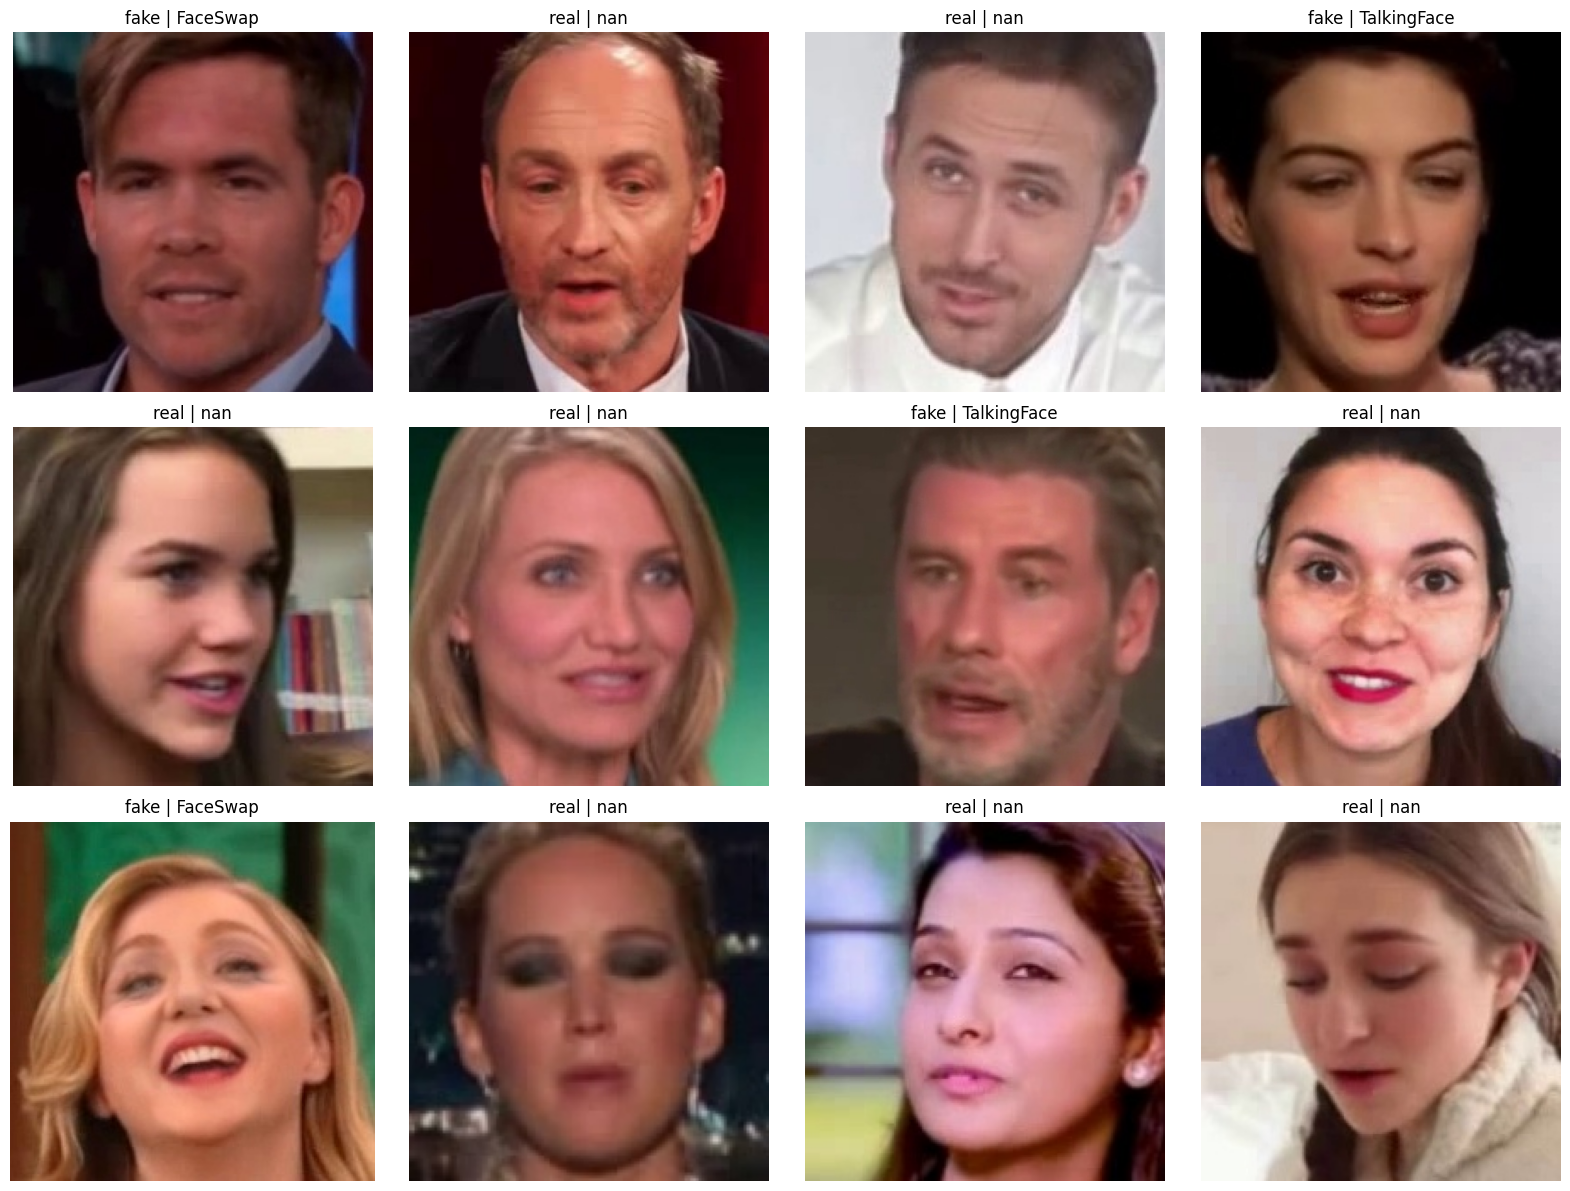

: 

In [ ]:
import matplotlib.pyplot as plt

def show_face_samples(face_df: pd.DataFrame, n: int = 12):
    if face_df.empty:
        print("No face crops available.")
        return
    sample_df = face_df.sample(min(n, len(face_df)), random_state=42).reset_index(drop=True)
    cols = 4
    rows = math.ceil(len(sample_df) / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, row in sample_df.iterrows():
        img = cv2.imread(str(row["face_path"]))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(rows, cols, i + 1)
        if img is not None:
            plt.imshow(img)
        plt.title(f'{row["label"]} | {row["manipulation_family"]}')
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_face_samples(face_manifest_df, n=SANITY_SAMPLES)

## Next stage

After this notebook, proceed to emotion annotation:

- input: `face_manifest.csv`
- output:
  - frame-level emotion predictions
  - video-level emotional descriptors:
    - dominant emotion
    - mean valence
    - mean arousal
    - max arousal
    - transition rate
    - entropy
    - neutral ratio